In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math

In [2]:
def preprocess_panoramic(gray):
    gray = gray.astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(gray)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (61, 61))
    background = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
    img = cv2.subtract(img, background)

    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    return img


def smooth_1d(arr, k=31):
    k = max(3, int(k))
    if k % 2 == 0:
        k += 1
    pad = k // 2
    padded = np.pad(arr, (pad, pad), mode="edge")
    kernel = np.ones(k, dtype=np.float32) / k
    return np.convolve(padded, kernel, mode="valid")


def build_edge_score(img, search_y_ratio=(0.55, 0.88)):
    h, w = img.shape
    y0 = int(search_y_ratio[0] * h)
    y1 = int(search_y_ratio[1] * h)

    roi = img[y0:y1, :]
    blur = cv2.GaussianBlur(roi, (5, 5), 0)

    gy = cv2.Sobel(blur, cv2.CV_32F, 0, 1, ksize=3)
    abs_gy = np.abs(gy)

    # favor lower pixels slightly so the path stays on the lower cortex
    rows = np.arange(abs_gy.shape[0], dtype=np.float32).reshape(-1, 1)
    row_bias = rows / max(1, abs_gy.shape[0] - 1)

    score = abs_gy + 25.0 * row_bias
    return score, y0


def find_best_path_dp(score, smooth_penalty=8.0, max_step=6):
    """
    Dynamic programming path finder.
    Finds one smooth path across columns of the score image.
    """
    H, W = score.shape
    dp = np.full((H, W), -1e18, dtype=np.float32)
    parent = np.full((H, W), -1, dtype=np.int32)

    dp[:, 0] = score[:, 0]

    for x in range(1, W):
        for y in range(H):
            y_prev_min = max(0, y - max_step)
            y_prev_max = min(H, y + max_step + 1)

            prev_rows = np.arange(y_prev_min, y_prev_max)
            penalties = smooth_penalty * np.abs(prev_rows - y)
            candidates = dp[y_prev_min:y_prev_max, x - 1] - penalties

            best_idx = np.argmax(candidates)
            best_prev_y = prev_rows[best_idx]

            dp[y, x] = score[y, x] + candidates[best_idx]
            parent[y, x] = best_prev_y

    path = np.zeros(W, dtype=np.int32)
    path[W - 1] = int(np.argmax(dp[:, W - 1]))

    for x in range(W - 1, 0, -1):
        path[x - 1] = parent[path[x], x]

    return path


def fit_cortex_paths(
    img,
    left_range=(0.12, 0.40),
    right_range=(0.60, 0.88),
    search_y_ratio=(0.55, 0.88),
    smooth_penalty=8.0,
    max_step=6,
    smooth_k=31
):
    h, w = img.shape
    score, y_offset = build_edge_score(img, search_y_ratio=search_y_ratio)

    def solve_side(x_range):
        x0 = int(x_range[0] * w)
        x1 = int(x_range[1] * w)
        side_score = score[:, x0:x1]

        path_local = find_best_path_dp(
            side_score,
            smooth_penalty=smooth_penalty,
            max_step=max_step
        )

        path_global_y = path_local.astype(np.float32) + y_offset
        path_global_y = smooth_1d(path_global_y, k=smooth_k)

        xs = np.arange(x0, x1)
        return xs, path_global_y

    left_xs, left_y = solve_side(left_range)
    right_xs, right_y = solve_side(right_range)

    return left_xs, left_y, right_xs, right_y


def sample_points_from_paths(
    left_xs, left_y, right_xs, right_y,
    max_points_total=20
):
    """
    Split max points roughly evenly between left and right.
    """
    left_n = max_points_total // 2
    right_n = max_points_total - left_n

    def sample_side(xs, ys, n):
        if len(xs) == 0 or n <= 0:
            return []
        idx = np.linspace(0, len(xs) - 1, n).astype(int)
        return [(int(xs[i]), int(ys[i])) for i in idx]

    left_points = sample_side(left_xs, left_y, left_n)
    right_points = sample_side(right_xs, right_y, right_n)

    return left_points + right_points


def make_box(img_shape, center_x, center_y, box_w, box_h, vertical_shift=0.0):
    h, w = img_shape

    cy = int(center_y + vertical_shift * box_h)

    x0 = int(center_x - box_w / 2)
    y0 = int(cy - box_h / 2)
    x1 = x0 + box_w
    y1 = y0 + box_h

    x0 = max(0, x0)
    y0 = max(0, y0)
    x1 = min(w, x1)
    y1 = min(h, y1)

    x0 = max(0, x1 - box_w)
    y0 = max(0, y1 - box_h)

    return (x0, y0, x1, y1)


def build_boxes_from_points(img_shape, points, box_w=150, box_h=150, vertical_shift=0.0):
    boxes = []
    for i, (x, y) in enumerate(points):
        box = make_box(img_shape, x, y, box_w, box_h, vertical_shift=vertical_shift)
        boxes.append({
            "name": f"crop_{i+1}",
            "center": (x, y),
            "box": box
        })
    return boxes


def crop_boxes(img, boxes):
    crops = []
    for item in boxes:
        x0, y0, x1, y1 = item["box"]
        crop = img[y0:y1, x0:x1]
        crops.append({
            "name": item["name"],
            "crop": crop,
            "box": item["box"],
            "center": item["center"]
        })
    return crops


def draw_debug_overlay(
    original_gray,
    left_xs, left_y,
    right_xs, right_y,
    points,
    boxes,
    left_range=(0.12, 0.40),
    right_range=(0.60, 0.88),
    search_y_ratio=(0.55, 0.88)
):
    h, w = original_gray.shape
    dbg = cv2.cvtColor(original_gray, cv2.COLOR_GRAY2BGR)

    # draw safe x zones
    lx0, lx1 = int(left_range[0] * w), int(left_range[1] * w)
    rx0, rx1 = int(right_range[0] * w), int(right_range[1] * w)
    cv2.rectangle(dbg, (lx0, 0), (lx1, h - 1), (255, 0, 0), 2)
    cv2.rectangle(dbg, (rx0, 0), (rx1, h - 1), (255, 0, 0), 2)

    # draw search y band
    sy0, sy1 = int(search_y_ratio[0] * h), int(search_y_ratio[1] * h)
    cv2.rectangle(dbg, (0, sy0), (w - 1, sy1), (0, 0, 255), 2)

    # draw fitted paths
    for x, y in zip(left_xs, left_y):
        cv2.circle(dbg, (int(x), int(y)), 1, (0, 255, 0), -1)
    for x, y in zip(right_xs, right_y):
        cv2.circle(dbg, (int(x), int(y)), 1, (0, 255, 0), -1)

    # sampled points
    for x, y in points:
        cv2.circle(dbg, (x, y), 4, (255, 255, 255), -1)

    # boxes
    for item in boxes:
        x0, y0, x1, y1 = item["box"]
        cv2.rectangle(dbg, (x0, y0), (x1, y1), (0, 255, 255), 2)
        cv2.putText(
            dbg,
            item["name"],
            (x0, max(20, y0 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 255),
            1
        )

    return dbg


def process_one_image_follow_cortex(
    image_path,
    left_range=(0.12, 0.40),
    right_range=(0.60, 0.88),
    search_y_ratio=(0.55, 0.88),
    smooth_penalty=8.0,
    max_step=6,
    smooth_k=31,
    max_points_total=20,
    box_w=150,
    box_h=150,
    vertical_shift=0.0
):
    gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f"Could not read image: {image_path}")

    processed = preprocess_panoramic(gray)

    left_xs, left_y, right_xs, right_y = fit_cortex_paths(
        processed,
        left_range=left_range,
        right_range=right_range,
        search_y_ratio=search_y_ratio,
        smooth_penalty=smooth_penalty,
        max_step=max_step,
        smooth_k=smooth_k
    )

    points = sample_points_from_paths(
        left_xs, left_y, right_xs, right_y,
        max_points_total=max_points_total
    )

    boxes = build_boxes_from_points(
        processed.shape,
        points,
        box_w=box_w,
        box_h=box_h,
        vertical_shift=vertical_shift
    )

    crops = crop_boxes(processed, boxes)

    debug_img = draw_debug_overlay(
        gray,
        left_xs, left_y,
        right_xs, right_y,
        points,
        boxes,
        left_range=left_range,
        right_range=right_range,
        search_y_ratio=search_y_ratio
    )

    return {
        "original": gray,
        "processed": processed,
        "left_xs": left_xs,
        "left_y": left_y,
        "right_xs": right_xs,
        "right_y": right_y,
        "points": points,
        "boxes": boxes,
        "crops": crops,
        "debug_img": debug_img
    }


def show_image(img, title="", figsize=(16, 8)):
    plt.figure(figsize=figsize)
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_crops(crops, cols=5, figsize=(18, 10)):
    if len(crops) == 0:
        print("No crops to show.")
        return

    rows = math.ceil(len(crops) / cols)
    plt.figure(figsize=figsize)

    for i, item in enumerate(crops, 1):
        plt.subplot(rows, cols, i)
        plt.imshow(item["crop"], cmap="gray")
        plt.title(item["name"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def save_crops(image_path, output_dir, crops):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    stem = Path(image_path).stem
    saved = []

    for item in crops:
        out_path = output_dir / f"{stem}_{item['name']}.png"
        cv2.imwrite(str(out_path), item["crop"])
        saved.append(str(out_path))

    return saved

In [10]:
# ---------- TEST IMAGE ----------
IMAGE_PATH = "Osteo_PR_Dataset\OP_Imgs_Raw\C3\images\OPHUB2021-0059.jpg"

LEFT_RANGE = (0.18, 0.36)
RIGHT_RANGE = (0.64, 0.82)

LEFT_SEARCH_Y_RATIO = (0.60, 0.85)
RIGHT_SEARCH_Y_RATIO = (0.60, 0.84)

MAX_POINTS_TOTAL = 12
BOX_W = 150
BOX_H = 150

# path smoothness
SMOOTH_PENALTY = 10.0
MAX_STEP = 5
SMOOTH_K = 35

# 0.0 = center box on detected cortex
# try -0.05 if you want a little more bone above the cortex
VERTICAL_SHIFT = -0.09

<>:2: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:2: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
C:\Users\zkx14\AppData\Local\Temp\ipykernel_23588\132948387.py:2: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  IMAGE_PATH = "Osteo_PR_Dataset\OP_Imgs_Raw\C3\images\OPHUB2021-0059.jpg"


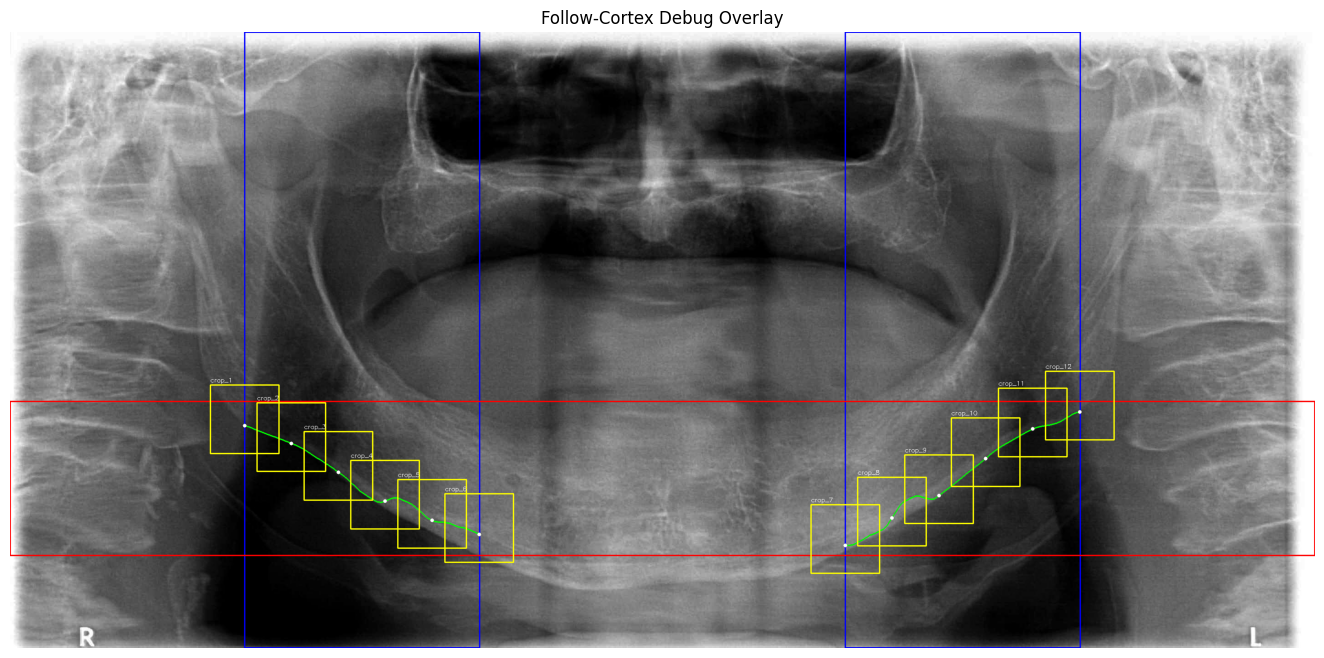

Number of boxes: 12


In [11]:
result = process_one_image_follow_cortex(
    image_path=IMAGE_PATH,
    left_range=LEFT_RANGE,
    right_range=RIGHT_RANGE,
    search_y_ratio=LEFT_SEARCH_Y_RATIO, # Using the left one for simplicity as it requires a single tuple
    smooth_penalty=SMOOTH_PENALTY,
    max_step=MAX_STEP,
    smooth_k=SMOOTH_K,
    max_points_total=MAX_POINTS_TOTAL,
    box_w=BOX_W,
    box_h=BOX_H,
    vertical_shift=VERTICAL_SHIFT
)

show_image(result["debug_img"], title="Follow-Cortex Debug Overlay", figsize=(18, 8))
#show_crops(result["crops"], cols=5, figsize=(18, 10))

print("Number of boxes:", len(result["boxes"]))


In [ ]:
from pathlib import Path
import cv2

INPUT_FOLDER = "Osteo_PR_Dataset\OP_Rolling_Ball_Imgs\C3"      # change this
OUTPUT_DEBUG = "processed_C3_img"      # debug overlay images
#OUTPUT_CROPS = "/mnt/data/output_crops"      # cropped patches

Path(OUTPUT_DEBUG).mkdir(parents=True, exist_ok=True)
#Path(OUTPUT_CROPS).mkdir(parents=True, exist_ok=True)

valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
image_files = [p for p in Path(INPUT_FOLDER).iterdir() if p.suffix.lower() in valid_exts]

print(f"Found {len(image_files)} images")

for img_path in image_files:
    try:
        result = process_one_image_follow_cortex(
            image_path=str(img_path),
            left_range=LEFT_RANGE,
            right_range=RIGHT_RANGE,
            search_y_ratio=LEFT_SEARCH_Y_RATIO,   # or SEARCH_Y_RATIO if that is your variable name
            smooth_penalty=SMOOTH_PENALTY,
            max_step=MAX_STEP,
            smooth_k=SMOOTH_K,
            max_points_total=MAX_POINTS_TOTAL,
            box_w=BOX_W,
            box_h=BOX_H,
            vertical_shift=VERTICAL_SHIFT
        )

        # save debug overlay
        debug_path = Path(OUTPUT_DEBUG) / f"{img_path.stem}_debug.png"
        cv2.imwrite(str(debug_path), result["debug_img"])

        # save crops
        #save_crops(str(img_path), OUTPUT_CROPS, result["crops"])

        print(f"Done: {img_path.name} | boxes={len(result['boxes'])}")

    except Exception as e:
        print(f"Failed: {img_path.name} -> {e}")

<>:4: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:4: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
C:\Users\zkx14\AppData\Local\Temp\ipykernel_13648\3829874998.py:4: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  INPUT_FOLDER = "Osteo_PR_Dataset\OP_Rolling_Ball_Imgs\C3"      # change this


Found 167 images
Done: OPHUB2015-0018.jpg | boxes=12
Done: OPHUB2015-0027.jpg | boxes=12
Done: OPHUB2015-0047.jpg | boxes=12
Done: OPHUB2015-0053.jpg | boxes=12
Done: OPHUB2015-0056.jpg | boxes=12
Done: OPHUB2017-0046.jpg | boxes=12
Done: OPHUB2017-0078.jpg | boxes=12
Done: OPHUB2017-0121.jpg | boxes=12
Done: OPHUB2017-0149.jpg | boxes=12
Done: OPHUB2017-0150.jpg | boxes=12
Done: OPHUB2017-0153.jpg | boxes=12
Done: OPHUB2017-0170.jpg | boxes=12
Done: OPHUB2017-0191.jpg | boxes=12
Done: OPHUB2018-0085.jpg | boxes=12
Done: OPHUB2018-0092.jpg | boxes=12
Done: OPHUB2018-0153.jpg | boxes=12
Done: OPHUB2018-0273.jpg | boxes=12
Done: OPHUB2018-0287.jpg | boxes=12
Done: OPHUB2018-0293.jpg | boxes=12
Done: OPHUB2018-0380.jpg | boxes=12
Done: OPHUB2018-0389.jpg | boxes=12
Done: OPHUB2018-0439.jpg | boxes=12
Done: OPHUB2018-0534.jpg | boxes=12
Done: OPHUB2018-0536.jpg | boxes=12
Done: OPHUB2018-0545.jpg | boxes=12
Done: OPHUB2018-0548.jpg | boxes=12
Done: OPHUB2018-0584.jpg | boxes=12
Done: OPHUB